# Exercises, Chapter 12: Transformations and regression

In [26]:
import numpy

from matplotlib import pyplot
from scipy import stats

In [27]:
_BASE_SEED = """Chapter 12, Transformation and regression

The intro talks about *standardization*, which "connects to 'regression to the
mean'" by putting predictors and outcomes on a shared zero-mean, unit-variance
scale.  And it also talks about "logarithmic and other transformations... in
order to get more understandable models and better predictions."
"""

def fresh_prng(seed: str):
    return numpy.random.default_rng(seed=abs(hash(seed + _BASE_SEED)) % (2 ** 32))

## 12.1 Plotting linear and quadratic regressions

> The folder `Earnings` has data on weight (in pounds), age (in years), and
> other information from a sample of American adults. We create a new variable,
> `age10 = age/10`, and fit the following regression predicting weight:

```
            Median MAD_SD
(Intercept) 148.7   2.2
age10         1.8   0.5

Auxiliary parameter(s):
      Median MAD_SD
sigma 34.5    0.6
```

> (a) With pen on paper, sketch a scatterplot of weights versus age (that is,
>     weight on y-axis, age on x-axis) that is consistent with the above
>     information, also drawing the fitted regression line. Do this just given
>     the information here and your general knowledge about adult heights and
>     weights; do not download the data.
>
> (b) Next, we define `age10_sq = (age/10)^2` and predict weight as a quadratic
>     function of age:

```
            Median MAD_SD
(Intercept) 108.0    5.7
age10        21.3    2.6
age10sq      -2.0    0.3

Auxiliary parameter(s):
      Median MAD_SD
sigma 33.9    0.6
```

> Draw this fitted curve on the graph you already sketched above.


In [28]:
rng = fresh_prng(".1 Plotting linear and quadratic regressions")

n = 150

In [29]:
age_mu = 40
age_sig = 13
ages = stats.truncnorm.rvs(
    (17 -age_mu) / age_sig,
    (110 - age_mu) / age_sig,
    loc=age_mu, 
    scale=age_sig,
    size=n
)

weights = stats.truncnorm.rvs(
    -1.7,
    100,
    loc=(148.7 + 0.18 * ages),
    scale=1.15 * 34.5,
    random_state=rng,
)

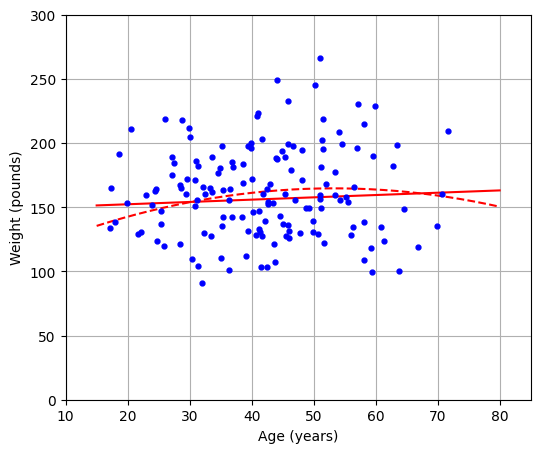

In [30]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    [15, 80],
    [148.7 + 0.18 * 15, 148.7 + 1.8 * 8],
    'r-',
    label='linear',
)
ax.plot(
    numpy.arange(15, 80, 0.1),
    [108 + 2.13 * ai - 0.02 * ai * ai for ai in numpy.arange(15, 80, 0.1)],
    'r--',
    label='quadratic',
)
ax.plot(ages, weights, 'b.', markersize=7)
ax.set_ylabel('Weight (pounds)')
ax.set_xlabel('Age (years)')
ax.grid()
ax.set_ylim(0, 300)
ax.set_xlim(10, 85)
ax.set_axisbelow(True)

## 12.2, Plotting regression with a continuous variable broken into categories

> Continuing Exercise 12.1, we divide age into 4 categories and create
> corresponding indicator variables, `age18_29`, `age30_44`, `age45_64`, and
> `age65_up`. We then fit the following regression:

```
   stan_glm(weight ~ age30_44 + age45_64 + age65_up, data=earnings)

            Median MAD_SD
(Intercept) 147.8    1.6
age30_44TRUE  9.6    2.1
age45_64TRUE 16.6    2.3
age65_upTRUE  7.5    2.7

Auxiliary parameter(s):
      Median MAD_SD
sigma 34.1    0.6
```

> (a) Why did we not include an indicator for the youngest group, `age18_29`?
>
> (b) Using the same axes and scale as in your graph for Exercise 12.1, sketch
>     with pen on paper the scatterplot, along with the above regression
>     function, which will be discontinuous.

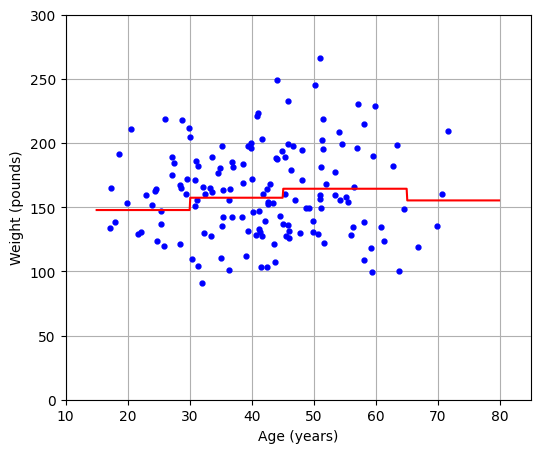

In [31]:
def discretized_age_model(age: float) -> float:
    intercept = 147.8
    if age < 30:
        return intercept
    if age < 45:
        return intercept + 9.6
    if age < 65:
        return intercept + 16.6
    return intercept + 7.5

fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(ages, weights, 'b.', markersize=7)
ax.plot(
    numpy.arange(15, 80, 0.1),
    [discretized_age_model(ai) for ai in numpy.arange(15, 80, 0.1)],
    'r-',
)
ax.set_ylabel('Weight (pounds)')
ax.set_xlabel('Age (years)')
ax.grid()
ax.set_ylim(0, 300)
ax.set_xlim(10, 85)
ax.set_axisbelow(True)

## 12.5, Logarithmic transformation and regression

> Consider the following regression:
>
> $$\log(\text{weight}) = -3.8 + 2.1 \log(\text{height}) + \text{error}$$
> 
> with errors that have standard deviation 0.25. Weights are in pounds and
> heights are in inches.
> 
> (a) Fill in the blanks: Approximately 68% of the people will have weights
>     within a factor of __ and of __ their predicted values from the
>     regression.
>
> (b) Using pen and paper, sketch the regression line and scatterplot of
>     log(weight) versus log(height) that make sense and are consistent with the
>     fitted model. Be sure to label the axes of your graph.

In [32]:
rng = fresh_prng(".5, Logarithmic transformation and regression")

n = 150

In [33]:
h_mu = 68
h_sig = 2.8
height = stats.truncnorm.rvs(
    (50 - h_mu) / h_sig,
    (84 - h_mu) / h_sig,
    loc=h_mu,
    scale=h_sig,
    size=50,
)
log_height = numpy.log(height)

log_weight = rng.normal(
    loc=(-3.8 + 2.1 * log_height),
    scale=0.25,
)

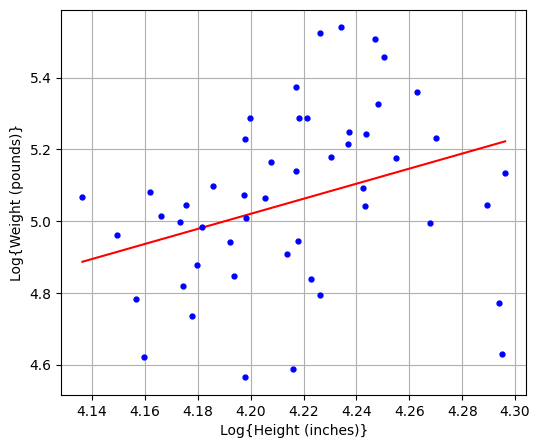

In [34]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    [min(log_height), max(log_height)],
    [-3.8 + 2.1 * lhi for lhi in [min(log_height), max(log_height)]],
    'r-',
)
ax.plot(log_height, log_weight, 'b.', markersize=7)
ax.set_ylabel('Log{Weight (pounds)}')
ax.set_xlabel('Log{Height (inches)}')
ax.grid()
ax.set_axisbelow(True)